# 01 - Data Understanding

Complete local notebook with saved outputs for GitHub rendering.


In [1]:
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
DATA_PATH = Path('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
PROCESSED_PATH = Path('../data/processed/retail_customers_cleaned.csv')
print('Environment ready')
print('Raw data path:', DATA_PATH)


Environment ready
Raw data path: ..\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv


In [2]:
df = pd.read_csv(DATA_PATH)
print('Raw dataset shape:', df.shape)
display(df.head())


Raw dataset shape: (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,17/07/10,Yes,59.252.219.201,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,2010-10-04,Yes,77.255.247.14,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,12/09/2009,Yes,51.139.78.80,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,28/01/10,Yes,10.212.80.124,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2009-12-10,Yes,186.34.121.80,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [3]:
columns_df = pd.DataFrame({
    'index': range(len(df.columns)),
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
})
print('Columns overview')
display(columns_df)


Columns overview


,index,column,dtype
0,0,CustomerID,int64
1,1,Recency,int64
2,2,Frequency,int64
3,3,MonetaryTotal,float64
4,4,MonetaryAvg,float64
5,5,MonetaryStd,float64
6,6,MonetaryMin,float64
7,7,MonetaryMax,float64
8,8,TotalQuantity,int64
9,9,AvgQuantityPerTransaction,float64


In [4]:
quality = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_values': df.isna().sum().values,
    'missing_rate': (df.isna().mean() * 100).round(2).values,
    'unique_values': df.nunique(dropna=False).values,
})
print('Data quality summary')
display(quality.sort_values(['missing_values', 'unique_values'], ascending=[False, False]).head(25))


Data quality summary


,column,dtype,missing_values,missing_rate,unique_values
30,Age,float64,1311,29.99,64
18,AvgDaysBetweenPurchases,float64,79,1.81,2641
0,CustomerID,int64,0,0.00,4372
33,LastLoginIP,str,0,0.00,4372
4,MonetaryAvg,float64,0,0.00,4330
3,MonetaryTotal,float64,0,0.00,4295
5,MonetaryStd,float64,0,0.00,4277
9,AvgQuantityPerTransaction,float64,0,0.00,3550
8,TotalQuantity,int64,0,0.00,1788
31,RegistrationDate,str,0,0.00,1700


In [5]:
print('Duplicated rows:', df.duplicated().sum())
print('Duplicated CustomerID:', df['CustomerID'].duplicated().sum() if 'CustomerID' in df.columns else 'CustomerID not found')


Duplicated rows: 0
Duplicated CustomerID: 0


In [6]:
churn_counts = df['Churn'].value_counts(dropna=False).rename_axis('Churn').reset_index(name='count')
churn_counts['rate_percent'] = (churn_counts['count'] / len(df) * 100).round(2)
print('Target distribution')
display(churn_counts)


Target distribution


,Churn,count,rate_percent
0,0,2918,66.74
1,1,1454,33.26


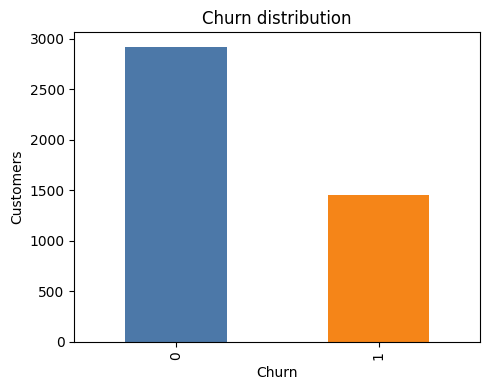

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind='bar', x='Churn', y='count', legend=False, ax=ax, color=['#4c78a8', '#f58518'])
ax.set_title('Churn distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.show()


In [8]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Number of numeric columns:', len(numeric_cols))
display(df[numeric_cols].describe().T.round(2).head(30))


Number of numeric columns: 34


,count,mean,std,min,25%,50%,75%,max
CustomerID,4372.0,15299.68,1722.39,12346.00,13812.75,15300.50,16778.25,18287.00
Recency,4372.0,92.05,100.77,1.00,17.00,50.00,143.00,374.00
Frequency,4372.0,5.08,9.34,1.00,1.00,3.00,5.00,248.00
MonetaryTotal,4372.0,1898.46,8219.35,-4287.63,293.36,648.08,1611.72,279489.02
MonetaryAvg,4372.0,28.84,127.32,-4287.63,10.99,16.92,23.54,3861.00
MonetaryStd,4372.0,88.67,2689.00,0.00,6.23,10.35,20.63,137554.85
MonetaryMin,4372.0,-86.43,2876.40,-168469.60,-11.50,0.79,6.96,3861.00
MonetaryMax,4372.0,185.18,2881.28,-4287.63,31.80,52.02,102.00,168469.60
TotalQuantity,4372.0,1122.34,4672.79,-303.00,153.00,365.00,962.25,196719.00
AvgQuantityPerTransaction,4372.0,22.39,213.26,-144.00,5.48,9.49,14.01,12540.00


In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Number of categorical columns:', len(categorical_cols))
display(pd.DataFrame({'column': categorical_cols, 'unique_values': [df[c].nunique(dropna=False) for c in categorical_cols]}).sort_values('unique_values', ascending=False))


Number of categorical columns: 18


C:\Users\USER\AppData\Local\Temp\ipykernel_18636\1912443879.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


,column,unique_values
2,LastLoginIP,4372
0,RegistrationDate,1700
17,Country,37
9,Region,13
4,AgeCategory,7
6,CustomerType,5
8,PreferredTimeOfDay,4
5,SpendingCategory,4
7,FavoriteSeason,4
3,RFMSegment,4


In [10]:
for col in ['RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'Region', 'LoyaltyLevel', 'Country']:
    if col in df.columns:
        print(); print('Top values for', col)
        display(df[col].value_counts(dropna=False).head(10).to_frame('count'))



Top values for RFMSegment


,count
RFMSegment,
Potentiels,1589
Fidèles,1177
Champions,979
Dormants,627



Top values for AgeCategory


,count
AgeCategory,
Inconnu,1311
65+,791
45-54,515
35-44,495
25-34,474
55-64,449
18-24,337



Top values for SpendingCategory


...

,count
Region,
UK,3959
Europe continentale,284
Europe du Nord,39
Europe du Sud,27
Europe centrale,16
Moyen-Orient,10
Océanie,9
Asie,9
Autre,8



Top values for LoyaltyLevel


,count
LoyaltyLevel,
Nouveau,1714
Établi,1588
Jeune,970
Ancien,100



Top values for Country


,count
Country,
United Kingdom,3950
Germany,95
France,87
Spain,30
Belgium,24
Switzerland,20
Portugal,19
Italy,15
Finland,12


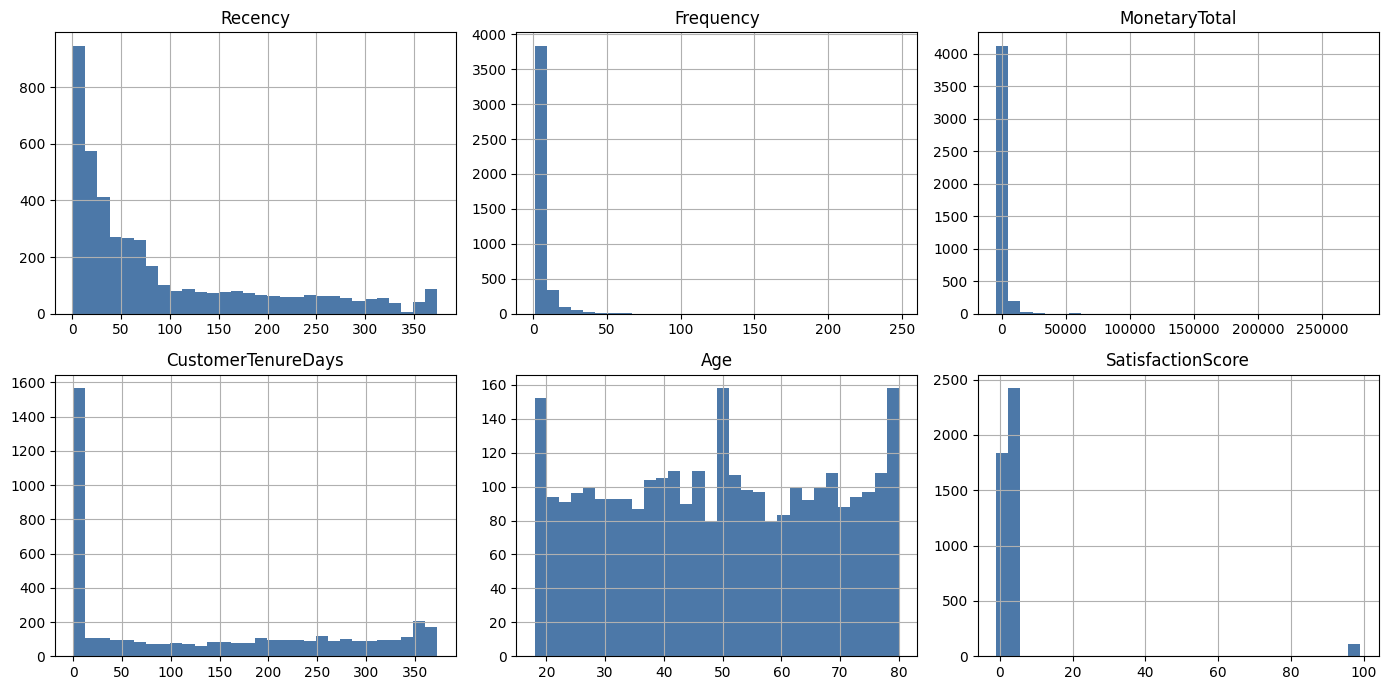

In [11]:
selected_numeric = [c for c in ['Recency', 'Frequency', 'MonetaryTotal', 'CustomerTenureDays', 'Age', 'SatisfactionScore'] if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for ax, col in zip(axes, selected_numeric):
    df[col].hist(ax=ax, bins=30, color='#4c78a8')
    ax.set_title(col)
for ax in axes[len(selected_numeric):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [12]:
check_cols = [c for c in ['SupportTicketsCount', 'SatisfactionScore', 'ZeroPriceCount', 'NegativeQuantityCount', 'CancelledTransactions'] if c in df.columns]
for col in check_cols:
    print(); print('Value counts for', col)
    display(df[col].value_counts(dropna=False).sort_index().head(20).to_frame('count'))



Value counts for SupportTicketsCount


,count
SupportTicketsCount,
-1.0,43
0.0,596
1.0,1140
2.0,1183
3.0,753
4.0,365
5.0,141
6.0,41
7.0,17



Value counts for SatisfactionScore


,count
SatisfactionScore,
-1.0,115
0.0,120
1.0,824
2.0,777
3.0,789
4.0,786
5.0,847
99.0,114



Value counts for ZeroPriceCount


,count
ZeroPriceCount,
0,4341
1,26
2,3
4,2



Value counts for NegativeQuantityCount


,count
NegativeQuantityCount,
0,2783
1,504
2,302
3,182
4,122
5,88
6,57
7,51
8,41



Value counts for CancelledTransactions


,count
CancelledTransactions,
0,2783
1,504
2,302
3,182
4,122
5,88
6,57
7,51
8,41


In [13]:
if 'RegistrationDate' in df.columns:
    parsed_dates = pd.to_datetime(df['RegistrationDate'], dayfirst=True, errors='coerce')
    print('RegistrationDate min:', parsed_dates.min())
    print('RegistrationDate max:', parsed_dates.max())
    print('Unparsed dates:', parsed_dates.isna().sum())


RegistrationDate min: 2009-06-12 00:00:00
RegistrationDate max: 2011-12-30 00:00:00
Unparsed dates: 0


C:\Users\USER\AppData\Local\Temp\ipykernel_18636\2881963852.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_dates = pd.to_datetime(df['RegistrationDate'], dayfirst=True, errors='coerce')


In [14]:
if 'Churn' in df.columns:
    numeric_by_churn = df.groupby('Churn')[selected_numeric].mean(numeric_only=True).round(2)
    print('Average numeric indicators by churn')
    display(numeric_by_churn)


Average numeric indicators by churn


,Recency,Frequency,MonetaryTotal,CustomerTenureDays,Age,SatisfactionScore
Churn,,,,,,
0,30.96,6.54,2557.67,175.90,49.41,5.18
1,214.65,2.13,575.51,48.06,48.63,5.63


In [15]:
correlation_cols = [c for c in selected_numeric + ['Churn'] if c in df.columns]
corr = df[correlation_cols].corr(numeric_only=True).round(3)
print('Correlation matrix for selected variables')
display(corr)


Correlation matrix for selected variables


,Recency,Frequency,MonetaryTotal,CustomerTenureDays,Age,SatisfactionScore,Churn
Recency,1.000,-0.259,-0.132,-0.516,-0.002,0.027,0.859
Frequency,-0.259,1.000,0.566,0.472,0.030,-0.015,-0.223
MonetaryTotal,-0.132,0.566,1.000,0.235,0.009,-0.012,-0.114
CustomerTenureDays,-0.516,0.472,0.235,1.000,0.026,-0.008,-0.453
Age,-0.002,0.030,0.009,0.026,1.000,-0.002,-0.020
SatisfactionScore,0.027,-0.015,-0.012,-0.008,-0.002,1.000,0.014
Churn,0.859,-0.223,-0.114,-0.453,-0.020,0.014,1.000


In [16]:
if PROCESSED_PATH.exists():
    processed = pd.read_csv(PROCESSED_PATH)
    print('Processed dataset shape:', processed.shape)
    display(processed.head())
else:
    print('Processed dataset not found')


Processed dataset shape: (4372, 56)


,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn,RegYear,RegMonth,RegDay,RegWeekday,IP_FirstOctet,IP_IsPrivate,MonetaryPerDay,AvgBasketValue,TenureRatio
0,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1,2010,7,17,5,59,0,17.454224,146.906389,4.194444
1,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0,2010,10,4,0,77,0,93.306061,162.057895,0.093294
2,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Semaine,Grand,Explorateur,Unknown,Active,France,0,2009,9,12,5,51,0,1796.835000,378.281053,0.008086
3,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1,2010,1,28,3,10,1,9.775773,158.041667,0.344086
4,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1,2009,12,10,3,186,0,1.918731,90.728571,7.500000


## Key observations

The raw dataset includes customer behavior, transaction aggregates, customer profile fields and the churn target. The next notebooks use the cleaned/preprocessed files saved in `data/processed` and `data/train_test`.
